# Task 3: CIFAR10 Classification with MLP

Train an MLP model on CIFAR10 dataset to achieve the highest possible accuracy using PyTorch.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from cifar10_mlp import CIFAR10MLP
import time
import os

os.environ['TORCH_HOME'] = './data'

import urllib.request
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


## Data Loading and Preprocessing

**Tips for faster download:**
1. If download is slow, you can manually download from: https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
2. Extract to `./data/cifar-10-batches-py/` directory
3. The code will automatically detect and skip download if dataset exists


In [5]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

data_dir = './data'
if os.path.exists(os.path.join(data_dir, 'cifar-10-batches-py')):
    print("CIFAR10 dataset found, skipping download...")
    download = False
else:
    print("CIFAR10 dataset not found, downloading...")
    download = True

trainset = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=download, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=download, transform=transform_test)

train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = random_split(trainset, [train_size, val_size])

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Training samples: {len(trainset)}, Validation samples: {len(valset)}, Test samples: {len(testset)}")


CIFAR10 dataset found, skipping download...
Training samples: 45000, Validation samples: 5000, Test samples: 10000


## Visualize Sample Images


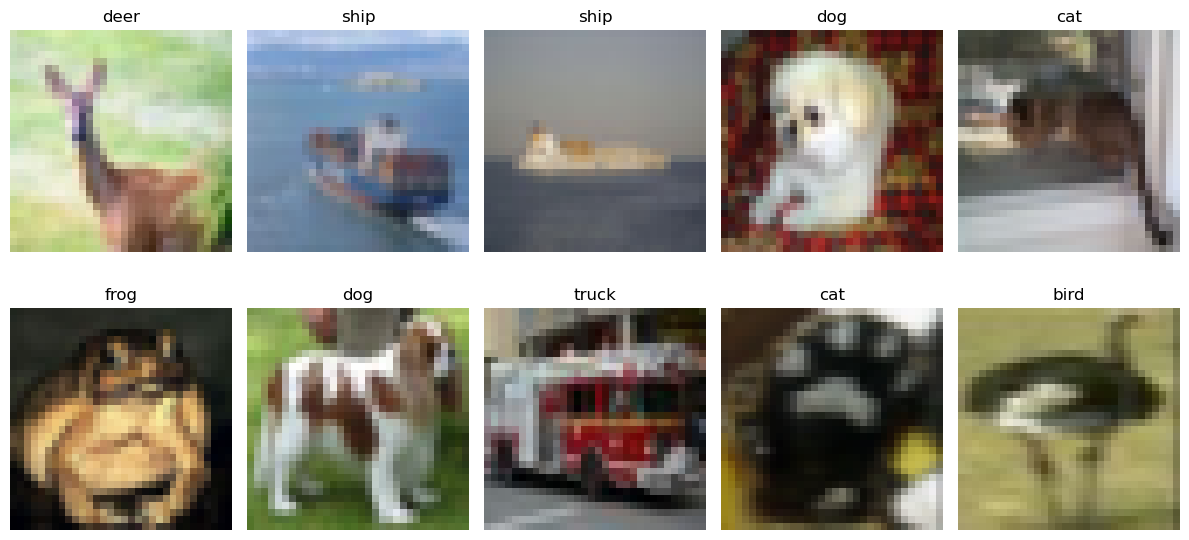

In [10]:
if 'trainloader' not in globals() or 'classes' not in globals():
    print("Error: Please run the data loading cell (Cell 3) first!")
else:
    def imshow(img, ax):
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        img = img.cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        img = std * img + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis('off')
    
    dataiter = iter(trainloader)
    images, labels = next(dataiter)
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for i in range(10):
        ax = axes[i // 5, i % 5]
        imshow(images[i], ax)
        ax.set_title(classes[labels[i].item()])
    plt.tight_layout()
    plt.show()


## Model Training


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = CIFAR10MLP(num_classes=10, hidden_units=[512, 512, 256, 256], dropout_rate=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

num_epochs = 50


Using device: cpu


/opt/anaconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [8]:
def train_epoch(model, trainloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(trainloader), 100. * correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(dataloader), 100. * correct / total


In [9]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
best_model_state = None

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, valloader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print('-' * 50)

elapsed_time = time.time() - start_time
print(f'Training completed in {elapsed_time/60:.2f} minutes')
print(f'Best validation accuracy: {best_val_acc:.2f}%')


Epoch [5/50]
Train Loss: 1.5703, Train Acc: 44.06%
Val Loss: 1.4434, Val Acc: 48.82%
--------------------------------------------------
Epoch [10/50]
Train Loss: 1.4827, Train Acc: 47.18%
Val Loss: 1.3734, Val Acc: 51.10%
--------------------------------------------------
Epoch [15/50]
Train Loss: 1.4393, Train Acc: 48.92%
Val Loss: 1.3263, Val Acc: 52.98%
--------------------------------------------------
Epoch [20/50]
Train Loss: 1.4145, Train Acc: 50.14%
Val Loss: 1.3082, Val Acc: 53.42%
--------------------------------------------------
Epoch [25/50]
Train Loss: 1.3981, Train Acc: 50.76%
Val Loss: 1.2963, Val Acc: 53.88%
--------------------------------------------------
Epoch [30/50]
Train Loss: 1.3842, Train Acc: 51.25%
Val Loss: 1.2682, Val Acc: 55.64%
--------------------------------------------------
Epoch [35/50]
Train Loss: 1.3737, Train Acc: 51.78%
Val Loss: 1.2748, Val Acc: 54.08%
--------------------------------------------------
Epoch [40/50]
Train Loss: 1.2901, Train Ac

## Load Best Model and Test


In [11]:
model.load_state_dict(best_model_state)
test_loss, test_acc = evaluate(model, testloader, criterion, device)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%')


Test Loss: 1.1774, Test Accuracy: 58.04%


## Training Curves Visualization


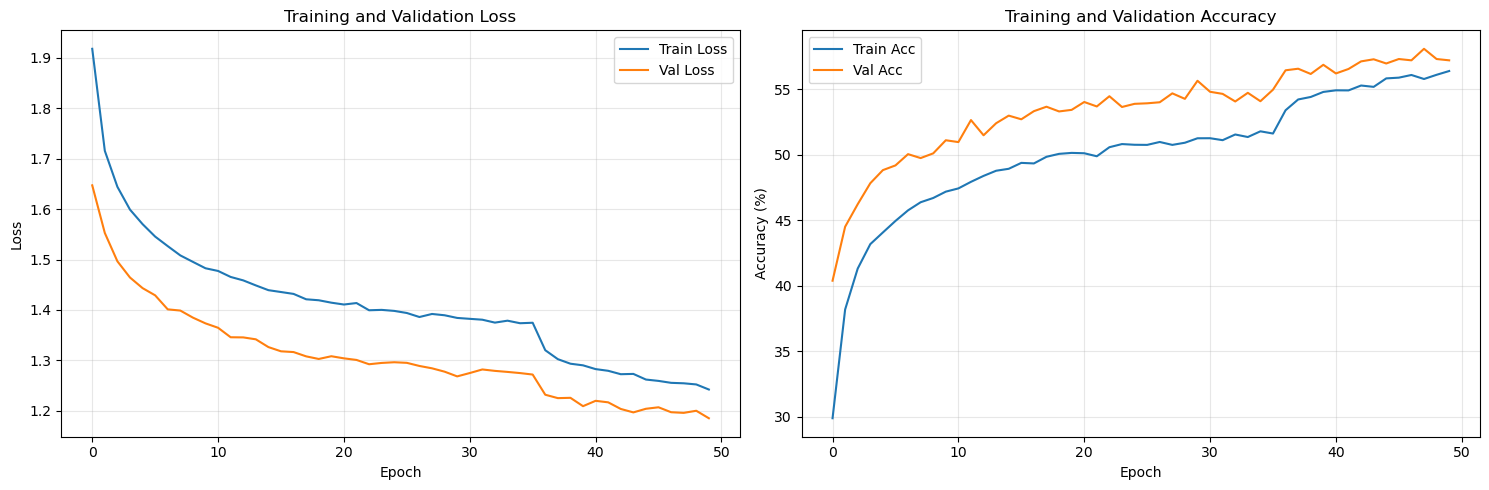

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Results and Analysis


### Summary

- **Model Architecture**: MLP with hidden layers [512, 512, 256, 256]
- **Optimization Techniques Used**:
  - Batch Normalization for stable training
  - Dropout (0.5) for regularization
  - Data augmentation (RandomHorizontalFlip)
  - Learning rate scheduling (ReduceLROnPlateau)
  - Weight decay (L2 regularization)
  - Adam optimizer

### Observations

1. MLP performance on CIFAR10 is limited compared to CNNs due to lack of spatial feature extraction
2. Deep MLP with proper regularization can still achieve reasonable accuracy
3. Batch normalization and dropout are crucial for training deep MLPs
4. Learning rate scheduling helps fine-tune the model in later epochs
